In [1]:
!pip install -q kagglehub nibabel segmentation-models

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 2.2 MB/s eta 0:00:00


In [2]:
import os, cv2, glob, random
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
print('TF:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TF: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import kagglehub
path = kagglehub.dataset_download(
    "awsaf49/brats20-dataset-training-validation"
)
print('Dataset path:', path)

Using Colab cache for faster access to the 'brats20-dataset-training-validation' dataset.
Dataset path: /kaggle/input/brats20-dataset-training-validation


In [4]:
flair_list = glob.glob(path + "/**/*_flair.nii", recursive=True)
training_images = []

for image_path in flair_list:
    mask_path = image_path.replace("_flair.nii", "_seg.nii")
    if os.path.exists(mask_path):
        training_images.append(image_path)

flair_list = training_images
print("Training Images:", len(flair_list))

Training Images: 368


In [5]:
IMG_SIZE = 128
LIMIT = 50
MIN_TUMOR_RATIO = 0.01

image_dataset = []
mask_dataset  = []

for image_path in flair_list[:LIMIT]:

    mask_path   = image_path.replace("_flair.nii", "_seg.nii")
    image_3d    = nib.load(image_path).get_fdata()
    mask_3d     = nib.load(mask_path).get_fdata()
    num_slices  = image_3d.shape[2]

    for s in range(num_slices):

        mask_slice  = mask_3d[:, :, s]
        tumor_ratio = np.sum(mask_slice > 0) / mask_slice.size

        if tumor_ratio < MIN_TUMOR_RATIO:
            continue

        image_slice = image_3d[:, :, s]

        image_slice = cv2.resize(image_slice, (IMG_SIZE, IMG_SIZE))
        mask_slice  = cv2.resize(mask_slice,  (IMG_SIZE, IMG_SIZE),
                                 interpolation=cv2.INTER_NEAREST)

        max_val = np.max(image_slice)
        if max_val > 0:
            image_slice = image_slice / max_val
        else:
            continue

        mask_slice[mask_slice > 0] = 1
        image_slice = np.stack((image_slice,) * 3, axis=-1)

        image_dataset.append(image_slice)
        mask_dataset.append(mask_slice)

print(f"Total slices loaded: {len(image_dataset)}")

Total slices loaded: 2487


In [6]:
X = np.array(image_dataset, dtype=np.float32)
y = np.array(mask_dataset,  dtype=np.float32)
y = np.expand_dims(y, axis=-1)

print('X shape:', X.shape)
print('y shape:', y.shape)


tumor_pixels = np.sum(y == 1)
bg_pixels    = np.sum(y == 0)
print(f"Tumor: {tumor_pixels:,} ({100*tumor_pixels/(tumor_pixels+bg_pixels):.1f}%)")
print(f"Background: {bg_pixels:,}")

X shape: (2487, 128, 128, 3)
y shape: (2487, 128, 128, 1)
Tumor: 1,442,282 (3.5%)
Background: 39,304,726


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('Train:', X_train.shape)
print('Test: ', X_test.shape)

Train: (1989, 128, 128, 3)
Test:  (498, 128, 128, 3)


In [8]:
def augment(image, mask):
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask  = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask  = tf.image.flip_up_down(mask)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, mask

BATCH_SIZE = 16

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(len(X_train))
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_size = int(0.1 * len(X_train))
val_ds = (
    tf.data.Dataset.from_tensor_slices((X_train[:val_size], y_train[:val_size]))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [9]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(128, 128, 3), include_top=False, weights='imagenet'
)

layer_names = [
    'block_1_expand_relu', 'block_3_expand_relu',
    'block_6_expand_relu', 'block_13_expand_relu',
    'block_16_project'
]
layers_output = [base_model.get_layer(n).output for n in layer_names]
down_stack = tf.keras.Model(inputs=base_model.input, outputs=layers_output)
down_stack.trainable = False

up_stack = [
    tf.keras.layers.Conv2DTranspose(512, 3, strides=2, padding='same', activation='relu'),
    tf.keras.layers.Conv2DTranspose(256, 3, strides=2, padding='same', activation='relu'),
    tf.keras.layers.Conv2DTranspose(128, 3, strides=2, padding='same', activation='relu'),
    tf.keras.layers.Conv2DTranspose(64,  3, strides=2, padding='same', activation='relu'),
]

inputs = tf.keras.layers.Input(shape=(128, 128, 3))
skips  = down_stack(inputs)
x      = skips[-1]
skips  = reversed(skips[:-1])

for up, skip in zip(up_stack, skips):
    x = up(x)
    x = tf.keras.layers.Concatenate()([x, skip])

x = tf.keras.layers.Conv2DTranspose(1, 3, strides=2, padding='same', activation='sigmoid')(x)
model = tf.keras.Model(inputs=inputs, outputs=x)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ [(None, 64, 64,   │  1,841,984 │ input_layer_1[0]… │
│ (Functional)        │ 96), (None, 32,   │            │                   │
│                     │ 32, 144), (None,  │            │                   │
│                     │ 16, 16, 192),     │            │                   │
│                     │ (None, 8, 8,      │            │                   │
│                     │ 576), (None, 4,   │            │                   │
│                     │ 4, 320)]          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 8, 8, 512) │  1,475,072 │ functional[0][4]  │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 8, 8,      │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 1088)             │            │ functional[0][3]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 16, 16,    │  2,507,008 │ concatenate[0][0] │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 448)              │            │ functional[0][2]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 32, 32,    │    516,224 │ concatenate_1[0]… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 272)              │            │ functional[0][1]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 64, 64,    │    156,736 │ concatenate_2[0]… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 160)              │            │ functional[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 128, 128,  │      1,441 │ concatenate_3[0]… │
│ (Conv2DTranspose)   │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,498,465 (24.79 MB)

 Trainable params: 4,656,481 (17.76 MB)

 Non-trainable params: 1,841,984 (7.03 MB)

In [10]:
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth
    )

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

bce = tf.keras.losses.BinaryCrossentropy()

def total_loss(y_true, y_pred):
    return bce(y_true, y_pred) + 2.0 * dice_loss(y_true, y_pred)

pos_ratio    = tumor_pixels / (tumor_pixels + bg_pixels)
class_weight = {0: 1.0, 1: 1.0 / (pos_ratio + 1e-6)}
print('Class weights:', class_weight)

Class weights: {0: 1.0, 1: np.float64(28.250963998541163)}


In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=total_loss,
    metrics=[dice_coef, 'accuracy']
)

In [12]:
callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-7, verbose=1
    ),
    ModelCheckpoint(
        'best_model.h5', monitor='val_dice_coef',
        mode='max', save_best_only=True, verbose=1
    )
]

In [13]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weight,
    callbacks=callbacks
)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.8178 - dice_coef: 0.1036 - loss: 4.2231
Epoch 1: val_dice_coef improved from None to 0.63812, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 69s 307ms/step - accuracy: 0.9267 - dice_coef: 0.2502 - loss: 3.3128 - val_accuracy: 0.9784 - val_dice_coef: 0.6381 - val_loss: 0.7757 - learning_rate: 1.0000e-04
Epoch 2/50
123/125 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9809 - dice_coef: 0.6810 - loss: 1.3390
Epoch 2: val_dice_coef improved from 0.63812 to 0.75220, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9817 - dice_coef: 0.7083 - loss: 1.2502 - val_accuracy: 0.9839 - val_dice_coef: 0.7522 - val_loss: 0.5419 - learning_rate: 1.0000e-04
Epoch 3/50
123/125 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9842 - dice_coef: 0.7554 - loss: 1.0599
Epoch 3: val_dice_coef improved from 0.75220 to 0.75348, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9848 - dice_coef: 0.7622 - loss: 1.0290 - val_accuracy: 0.9824 - val_dice_coef: 0.7535 - val_loss: 0.5397 - learning_rate: 1.0000e-04
Epoch 4/50
123/125 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9861 - dice_coef: 0.7813 - loss: 0.9414
Epoch 4: val_dice_coef improved from 0.75348 to 0.79609, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9865 - dice_coef: 0.7875 - loss: 0.9182 - val_accuracy: 0.9876 - val_dice_coef: 0.7961 - val_loss: 0.4444 - learning_rate: 1.0000e-04
Epoch 5/50
123/125 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9870 - dice_coef: 0.7939 - loss: 0.8897
Epoch 5: val_dice_coef improved from 0.79609 to 0.81361, saving model to best_model.h5


...


Epoch 42: finished saving model to best_model.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9950 - dice_coef: 0.9223 - loss: 0.3394 - val_accuracy: 0.9952 - val_dice_coef: 0.9253 - val_loss: 0.1654 - learning_rate: 1.0000e-04
Epoch 43/50
123/125 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9950 - dice_coef: 0.9219 - loss: 0.3405
Epoch 43: val_dice_coef did not improve from 0.92526
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9950 - dice_coef: 0.9218 - loss: 0.3412 - val_accuracy: 0.9952 - val_dice_coef: 0.9240 - val_loss: 0.1685 - learning_rate: 1.0000e-04
Epoch 44/50
123/125 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9952 - dice_coef: 0.9248 - loss: 0.3276
Epoch 44: val_dice_coef improved from 0.92526 to 0.92842, saving model to best_model.h5



Epoch 44: finished saving model to best_model.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9952 - dice_coef: 0.9248 - loss: 0.3274 - val_accuracy: 0.9954 - val_dice_coef: 0.9284 - val_loss: 0.1590 - learning_rate: 1.0000e-04
Epoch 45/50
123/125 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9954 - dice_coef: 0.9280 - loss: 0.3154
Epoch 45: val_dice_coef did not improve from 0.92842
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9953 - dice_coef: 0.9267 - loss: 0.3199 - val_accuracy: 0.9953 - val_dice_coef: 0.9276 - val_loss: 0.1607 - learning_rate: 1.0000e-04
Epoch 46/50
123/125 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9953 - dice_coef: 0.9265 - loss: 0.3220
Epoch 46: val_dice_coef did not improve from 0.92842
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9953 - dice_coef: 0.9260 - loss: 0.3232 - val_accuracy: 0.9953 - val_dice_coef: 0.9262 - val_loss: 0.1636 - learning_rate: 1.0000e-04
Epoch 47/50
123/125 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - ac


Epoch 48: finished saving model to best_model.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9954 - dice_coef: 0.9273 - loss: 0.3181 - val_accuracy: 0.9955 - val_dice_coef: 0.9303 - val_loss: 0.1553 - learning_rate: 1.0000e-04
Epoch 49/50
123/125 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9955 - dice_coef: 0.9298 - loss: 0.3077
Epoch 49: val_dice_coef improved from 0.93032 to 0.93125, saving model to best_model.h5



Epoch 49: finished saving model to best_model.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9955 - dice_coef: 0.9296 - loss: 0.3074 - val_accuracy: 0.9956 - val_dice_coef: 0.9313 - val_loss: 0.1525 - learning_rate: 1.0000e-04
Epoch 50/50
123/125 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9955 - dice_coef: 0.9291 - loss: 0.3090
Epoch 50: val_dice_coef improved from 0.93125 to 0.93335, saving model to best_model.h5



Epoch 50: finished saving model to best_model.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9956 - dice_coef: 0.9305 - loss: 0.3037 - val_accuracy: 0.9957 - val_dice_coef: 0.9334 - val_loss: 0.1475 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 50.


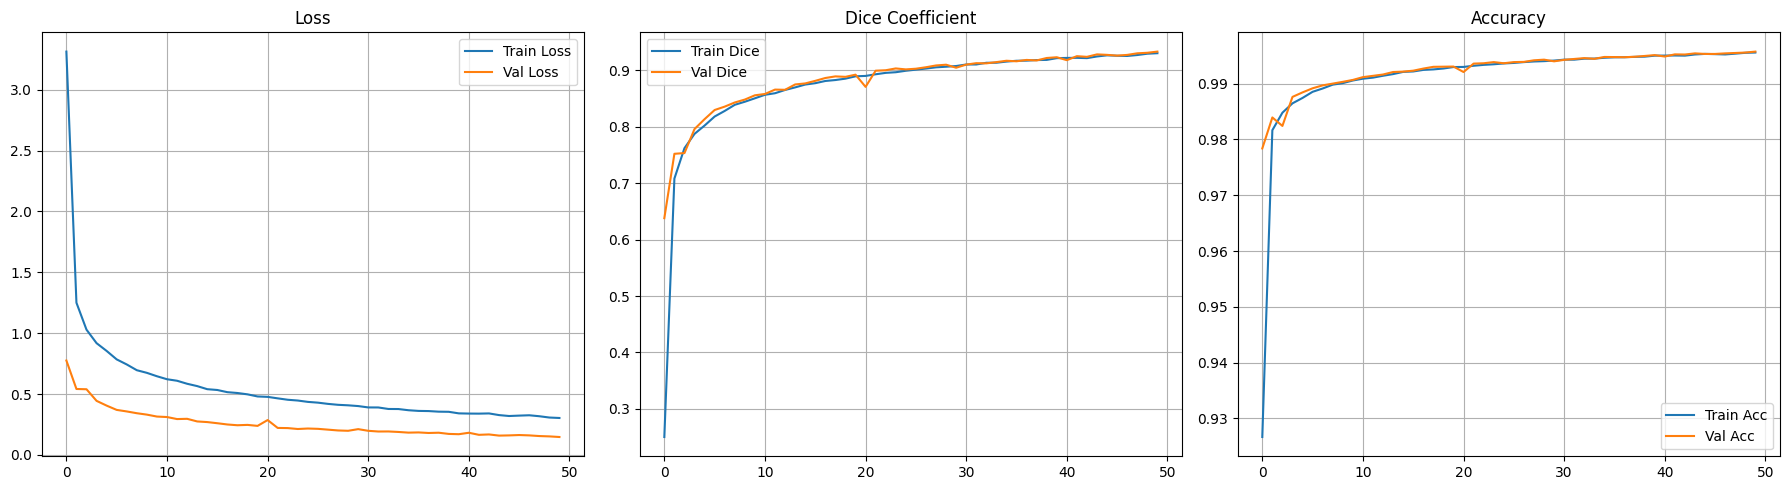

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['dice_coef'],     label='Train Dice')
axes[1].plot(history.history['val_dice_coef'], label='Val Dice')
axes[1].set_title('Dice Coefficient'); axes[1].legend(); axes[1].grid(True)

axes[2].plot(history.history['accuracy'],     label='Train Acc')
axes[2].plot(history.history['val_accuracy'], label='Val Acc')
axes[2].set_title('Accuracy'); axes[2].legend(); axes[2].grid(True)

plt.tight_layout(); plt.show()

In [15]:
results = model.evaluate(X_test, y_test, verbose=1)
print(f'Loss:      {results[0]:.4f}')
print(f'Dice Coef: {results[1]:.4f}')
print(f'Accuracy:  {results[2]:.4f}')

16/16 ━━━━━━━━━━━━━━━━━━━━ 27s 874ms/step - accuracy: 0.9950 - dice_coef: 0.9263 - loss: 0.1657
Loss:      0.1657
Dice Coef: 0.9263
Accuracy:  0.9950


16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 331ms/step


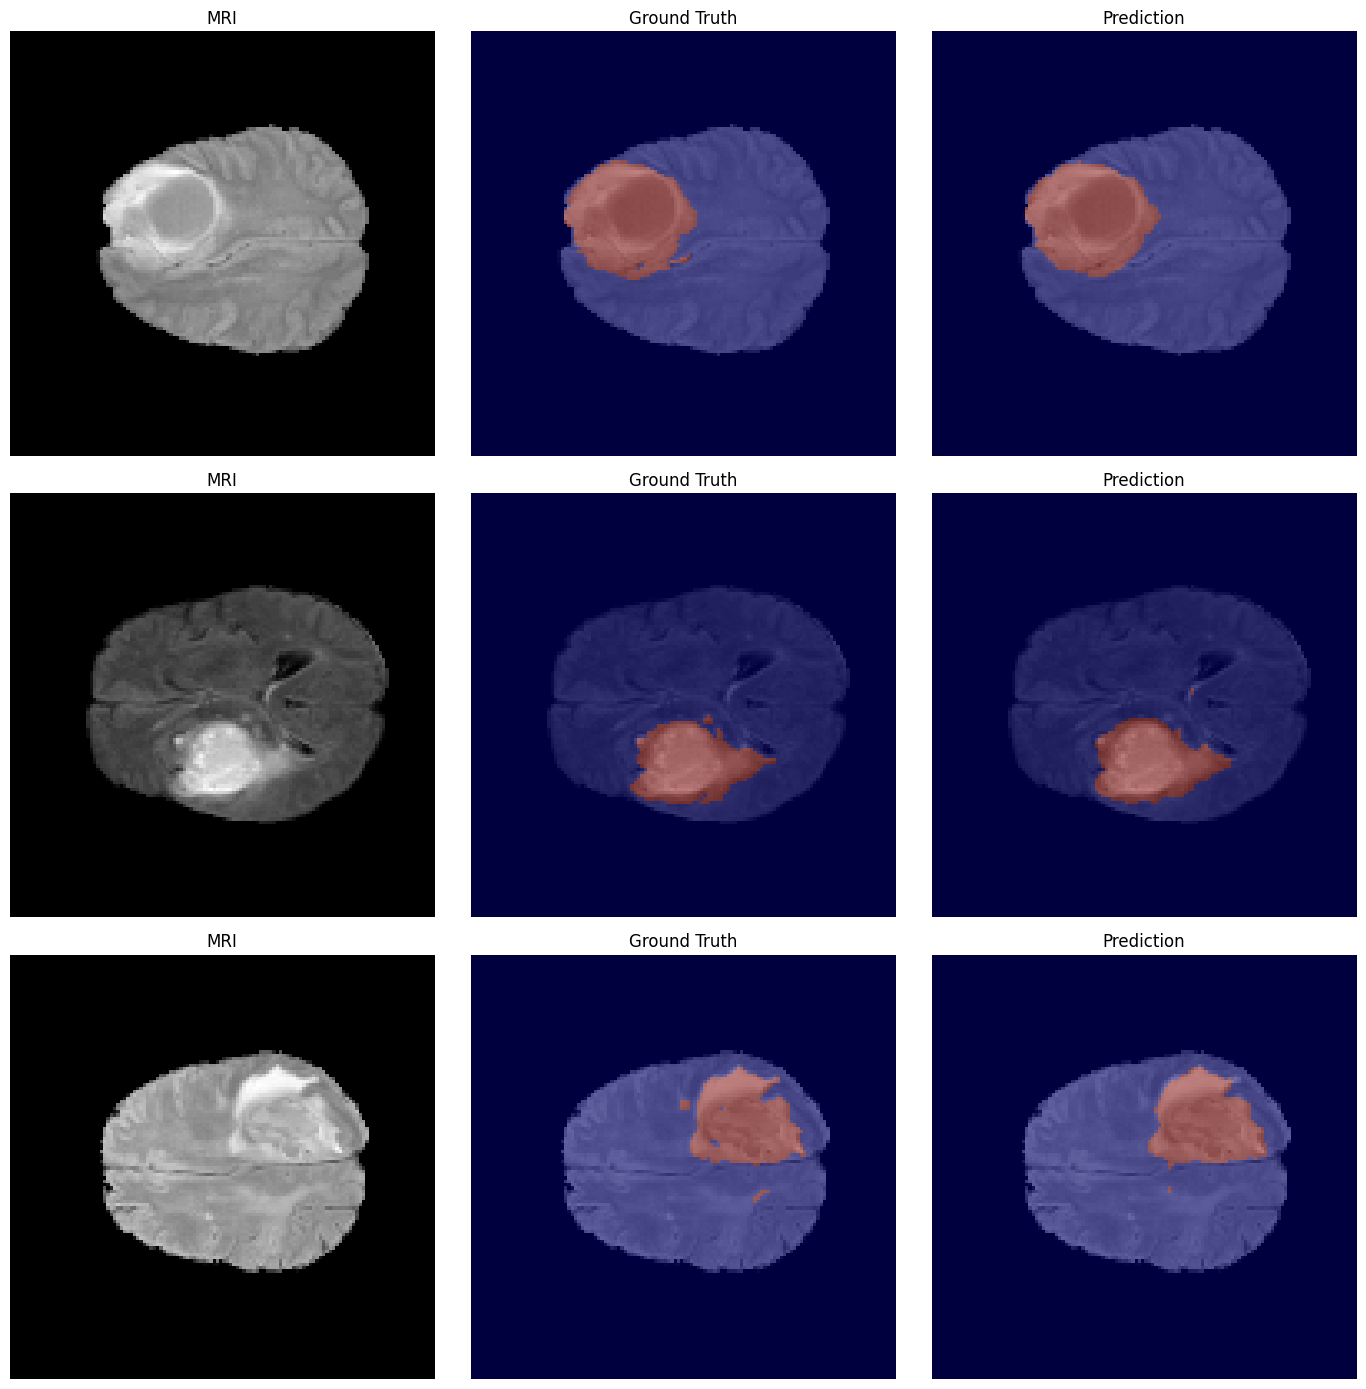

In [16]:
preds = model.predict(X_test)
preds = (preds > 0.5).astype(np.uint8)

fig, axes = plt.subplots(3, 3, figsize=(14, 14))

for row in range(3):
    index     = random.randint(0, len(X_test) - 1)
    img       = X_test[index]
    real_mask = y_test[index].squeeze()
    pred_mask = preds[index].squeeze()

    axes[row, 0].imshow(img[:, :, 0], cmap='gray')
    axes[row, 0].set_title('MRI'); axes[row, 0].axis('off')

    axes[row, 1].imshow(img[:, :, 0], cmap='gray')
    axes[row, 1].imshow(real_mask, cmap='jet', alpha=0.5)
    axes[row, 1].set_title('Ground Truth'); axes[row, 1].axis('off')

    axes[row, 2].imshow(img[:, :, 0], cmap='gray')
    axes[row, 2].imshow(pred_mask, cmap='jet', alpha=0.5)
    axes[row, 2].set_title('Prediction'); axes[row, 2].axis('off')

plt.tight_layout(); plt.show()

In [17]:
model.save('brain_tumor_segmentation.h5')
print('Model saved!')

Model saved!


In [18]:
!pip install -q gradio

In [20]:
import gradio as gr
import numpy as np
import tensorflow as tf
import cv2

model = tf.keras.models.load_model(
    'brain_tumor_segmentation.h5', compile=False
)
IMG_SIZE = 128

def predict(image):
    img = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32)

    max_val = np.max(img)
    if max_val > 0:
        img = img / max_val

    img  = np.expand_dims(img, axis=0)
    pred = model.predict(img)[0]
    mask = (pred > 0.5).astype(np.uint8).squeeze()

    color_mask = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    color_mask[mask == 1] = [255, 0, 0]

    gray    = (img[0, :, :, 0] * 255).astype(np.uint8)
    rgb     = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    overlay = cv2.addWeighted(rgb, 0.7, color_mask, 0.3, 0)
    return overlay

app = gr.Interface(
    fn=predict,
    inputs=gr.Image(type='numpy', label='Upload MRI'),
    outputs=gr.Image(label='Tumor Segmentation'),
    title='Brain Tumor Segmentation',
    description='Upload an MRI image and get the tumor segmentation.',)
app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5d12234e463d9433ad.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
